In [1]:
import pandas as pd
import os

ruta = r"D:\anazamora\2026\blogprogramacion\Analisis_datos_FIFA2026\archive"

In [3]:
#%pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: D:\anazamora\Python\python.exe -m pip install --upgrade pip


In [2]:
archivos = {}

for archivo in os.listdir(ruta):

    if archivo.endswith(".xlsx"):

        nombre = archivo.replace(".xlsx","")

        archivos[nombre] = pd.read_excel(os.path.join(ruta,archivo))

print(archivos.keys())

D:\anazamora\Python\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
D:\anazamora\Python\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
D:\anazamora\Python\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
D:\anazamora\Python\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
D:\anazamora\Python\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply 

dict_keys(['ball_livedata', 'events', 'players', 'post_match_average_position', 'post_match_details', 'post_match_incidents', 'post_match_momentum', 'post_match_shots', 'post_match_stats', 'post_match_xg'])


In [3]:
for nombre, df in archivos.items():

    print("="*60)
    print(nombre)

    print(df.shape)

ball_livedata
(99482, 20)
events
(16860, 218)
players
(1258, 20)
post_match_average_position
(3043, 9)
post_match_details
(98, 37)
post_match_incidents
(1958, 25)
post_match_momentum
(9067, 4)
post_match_shots
(2467, 23)
post_match_stats
(98, 141)
post_match_xg
(1931, 7)


In [4]:
for nombre, df in archivos.items():

    print("\n")
    print("="*80)

    print(nombre.upper())

    print("="*80)

    print(df.columns.tolist())



BALL_LIVEDATA
['event_id', 'display', 'side', 'situation', 'commentary', 'minute', 'second', 'period', 'additional_time', 'uts', 'period_started_at_uts', 'coord_1_x', 'coord_1_y', 'coord_2_x', 'coord_2_y', 'coord_3_x', 'coord_3_y', 'coord_4_x', 'coord_4_y', 'received_at']


EVENTS
['home_short_name', 'away_short_name', 'event_id', 'home_id', 'home_name', 'away_id', 'away_name', 'score_home', 'score_away', 'time_minute', 'time_second', 'time_display', 'time_period', 'additional_time', 'time_period_started_at_uts', 'time_status', 'time_kickoff_at', 'home_duels', 'home_fouls', 'home_passes', 'home_corners', 'home_Offsides', 'home_duel_won', 'home_red_cards', 'home_big_chance', 'home_clearances', 'home_aerials_won_value', 'home_aerials_won_pct', 'home_accurate_passes_value', 'home_accurate_passes_pct', 'home_accurate_crosses_value', 'home_accurate_crosses_pct', 'home_ground_duels_won_value', 'home_ground_duels_won_pct', 'home_dribbles_succeeded_value', 'home_dribbles_succeeded_pct', 'hom

In [5]:
matches = archivos["post_match_details"].copy()
stats = archivos["post_match_stats"].copy()

matches = matches.merge(
    stats,
    on="event_id",
    how="left"
)

print(matches.shape)
matches.head()

(98, 177)


,event_id,home_team,away_team,weather,highlights,season_id,home_team_id,away_team_id,home_coach_id,away_coach_id,...,away_final_third_phase_value,away_final_third_phase_total,away_final_third_phase_pct,away_xg_actual,away_punches,away_high_claims,away_errors_lead_to_a_shot,away_errors_lead_to_a_goal,away_red_cards,away_penalty_saves
0,8287.0,Mexico,South Africa,"{\n ""code"" : 2,\n ""description"" : ""cloudy"",\...","[ {\n ""kind"" : ""clip"",\n ""title"" : ""Press Co...",188.0,451.0,452.0,128.0,87.0,...,25.0,56.0,45.0,0.07,1.0,2.0,1.0,1.0,2.0,NaN
1,8288.0,South Korea,Czechia,"{\n ""code"" : 2,\n ""description"" : ""cloudy"",\...","[ {\n ""kind"" : ""clip"",\n ""title"" : ""Press Co...",188.0,453.0,930.0,105.0,579.0,...,53.0,103.0,51.0,0.81,NaN,NaN,NaN,NaN,NaN,NaN
2,8289.0,Canada,Bosnia & Herzegovina,"{\n ""code"" : 2,\n ""description"" : ""cloudy"",\...","[ {\n ""kind"" : ""clip"",\n ""title"" : ""Press Co...",188.0,455.0,931.0,130.0,580.0,...,35.0,79.0,44.0,0.96,0.0,3.0,2.0,NaN,NaN,NaN
3,8290.0,USA,Paraguay,"{\n ""code"" : 1,\n ""description"" : ""clear"",\n...","[ {\n ""kind"" : ""clip"",\n ""title"" : ""Press Co...",188.0,457.0,458.0,122.0,90.0,...,17.0,47.0,36.0,0.47,NaN,0.0,2.0,NaN,NaN,NaN
4,8292.0,Qatar,Switzerland,"{\n ""code"" : 2,\n ""description"" : ""cloudy"",\...","[ {\n ""kind"" : ""full"",\n ""title"" : ""Qatar 1 ...",188.0,461.0,462.0,570.0,78.0,...,197.0,229.0,86.0,3.24,0.0,0.0,1.0,NaN,NaN,NaN


In [6]:
print(f"Total de partidos: {len(matches)}")

Total de partidos: 98


In [7]:
matches["total_goals"] = (
    matches["home_score"] +
    matches["away_score"]
)

print(f"Goles totales: {matches['total_goals'].sum()}")

print(f"Promedio por partido: {matches['total_goals'].mean():.2f}")

Goles totales: 281.0
Promedio por partido: 2.87


In [8]:
home_wins = (matches.home_score > matches.away_score).sum()

away_wins = (matches.away_score > matches.home_score).sum()

draws = (matches.home_score == matches.away_score).sum()

print(f"Victorias Local : {home_wins}")
print(f"Victorias Visita: {away_wins}")
print(f"Empates         : {draws}")

Victorias Local : 46
Victorias Visita: 26
Empates         : 26


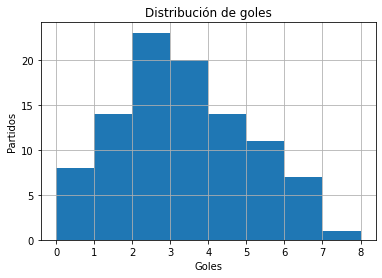

In [9]:
import matplotlib.pyplot as plt

matches["total_goals"].hist(
    bins=8
)

plt.xlabel("Goles")

plt.ylabel("Partidos")

plt.title("Distribución de goles")

plt.show()

In [10]:
matches["total_goals"] = (
    matches["home_score"] +
    matches["away_score"]
)

In [11]:
matches.loc[
    matches["total_goals"] == 0,
    [
        "event_date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "total_goals"
    ]
].sort_values("event_date")

,event_date,home_team,away_team,home_score,away_score,total_goals
12,2026-06-15T16:00:00+00:00,Spain,Cabo Verde,0.0,0.0,0.0
34,2026-06-21T00:00:00+00:00,Ecuador,Curaçao,0.0,0.0,0.0
37,2026-06-21T19:00:00+00:00,Belgium,Iran,0.0,0.0,0.0
45,2026-06-23T20:00:00+00:00,England,Ghana,0.0,0.0,0.0
58,2026-06-26T02:00:00+00:00,Paraguay,Australia,0.0,0.0,0.0
62,2026-06-27T00:00:00+00:00,Cabo Verde,Saudi Arabia,0.0,0.0,0.0
69,2026-06-27T23:30:00+00:00,Colombia,Portugal,0.0,0.0,0.0
95,2026-07-07T20:00:00+00:00,Switzerland,Colombia,0.0,0.0,0.0


In [12]:

#Promedio de tiros
print("Tiros Local")

print(matches.home_total_shots.mean())

print()

print("Tiros Visitante")

print(matches.away_total_shots.mean())

Tiros Local
13.877551020408163

Tiros Visitante
10.73469387755102


In [13]:
#Tiros al arco
print(matches.home_shots_on_target.mean())

print(matches.away_shots_on_target.mean())

4.755102040816326
3.5918367346938775


In [14]:
#Precisión de pase
print(matches.home_pass_accuracy_pct.mean())

print(matches.away_pass_accuracy_pct.mean())

84.51326530612243
82.53061224489795


In [15]:
#Goles promedio
print("xG Local")

print(matches.home_expected_goals.mean())

print()

print("xG Visitante")

print(matches.away_expected_goals.mean())

xG Local
1.483775510204082

xG Visitante
1.0362244897959185


In [16]:
#Tarjetas amarillas en 98 partidos
print("Amarillas Local")

print(matches.home_yellow_cards.sum())

print()

print("Amarillas Visitante")

print(matches.away_yellow_cards.sum())

Amarillas Local
110.0

Amarillas Visitante
140.0


In [17]:
total_partidos = len(matches)

amarillas = (
    matches["home_yellow_cards"].sum() +
    matches["away_yellow_cards"].sum()
)

rojas = (
    matches["home_red_cards"].sum() +
    matches["away_red_cards"].sum()
)

print(f"Partidos: {total_partidos}")
print(f"Amarillas: {amarillas}")
print(f"Rojas: {rojas}")

print(f"Amarillas por partido: {amarillas/total_partidos:.2f}")
print(f"Rojas por partido: {rojas/total_partidos:.2f}")

Partidos: 98
Amarillas: 250.0
Rojas: 13.0
Amarillas por partido: 2.55
Rojas por partido: 0.13


In [18]:
ranking = (
    matches[
        [
            "home_team",
            "home_score"
        ]
    ]
    .rename(
        columns={
            "home_team":"team",
            "home_score":"goals"
        }
    )
)

ranking2 = (
    matches[
        [
            "away_team",
            "away_score"
        ]
    ]
    .rename(
        columns={
            "away_team":"team",
            "away_score":"goals"
        }
    )
)

ranking = pd.concat(
    [
        ranking,
        ranking2
    ]
)

ranking = (
    ranking
    .groupby("team")
    .sum()
    .sort_values(
        "goals",
        ascending=False
    )
)

ranking.head(10)

,goals
team,
France,16.0
Belgium,13.0
Argentina,12.0
Norway,12.0
USA,11.0
Germany,11.0
Spain,11.0
England,11.0
Netherlands,11.0


In [19]:
posesion = pd.concat([
    matches[["home_team","home_ball_possession"]].rename(
        columns={
            "home_team":"team",
            "home_ball_possession":"possession"
        }
    ),
    matches[["away_team","away_ball_possession"]].rename(
        columns={
            "away_team":"team",
            "away_ball_possession":"possession"
        }
    )
])

posesion = (
    posesion
    .groupby("team")
    .mean()
    .sort_values(
        "possession",
        ascending=False
    )
)

posesion.head(10)

,possession
team,
Türkiye,66.0
Spain,66.0
Germany,65.0
South Korea,63.0
Algeria,61.0
Argentina,60.6
Morocco,59.0
France,59.0
Portugal,58.4


In [20]:
ataque_local = matches[["home_team", "home_score", "home_total_shots"]].rename(
    columns={
        "home_team": "team",
        "home_score": "goals",
        "home_total_shots": "shots"
    }
)

ataque_visitante = matches[["away_team", "away_score", "away_total_shots"]].rename(
    columns={
        "away_team": "team",
        "away_score": "goals",
        "away_total_shots": "shots"
    }
)

ataque = pd.concat([ataque_local, ataque_visitante])

resumen = (
    ataque
    .groupby("team")[["goals", "shots"]]
    .sum()
)

resumen["conversion_pct"] = (
    resumen["goals"] / resumen["shots"] * 100
).round(2)

resumen.sort_values("conversion_pct", ascending=False).head(10)

,goals,shots,conversion_pct
team,,,
Netherlands,11.0,46.0,23.91
Japan,8.0,34.0,23.53
Norway,12.0,54.0,22.22
Austria,6.0,32.0,18.75
USA,11.0,59.0,18.64
France,16.0,98.0,16.33
Croatia,6.0,37.0,16.22
Argentina,12.0,75.0,16.00
Sweden,7.0,47.0,14.89


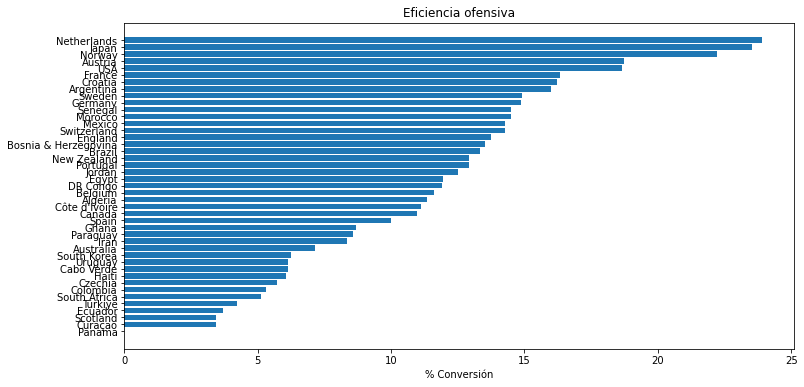

In [21]:
ataque_local = matches[
    ["home_team","home_score","home_total_shots"]
].rename(columns={
    "home_team":"team",
    "home_score":"goals",
    "home_total_shots":"shots"
})

ataque_visitante = matches[
    ["away_team","away_score","away_total_shots"]
].rename(columns={
    "away_team":"team",
    "away_score":"goals",
    "away_total_shots":"shots"
})

ataque = pd.concat([ataque_local, ataque_visitante])

eficiencia = (
    ataque
    .groupby("team")[["goals","shots"]]
    .sum()
)

eficiencia["conversion"] = (
    eficiencia["goals"] /
    eficiencia["shots"] * 100
)

# quitar equipos con pocos tiros
eficiencia = eficiencia[eficiencia["shots"] >= 20]

eficiencia = eficiencia.sort_values(
    "conversion",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.barh(
    eficiencia.index,
    eficiencia["conversion"]
)

plt.xlabel("% Conversión")

plt.title("Eficiencia ofensiva")

plt.gca().invert_yaxis()

plt.show()

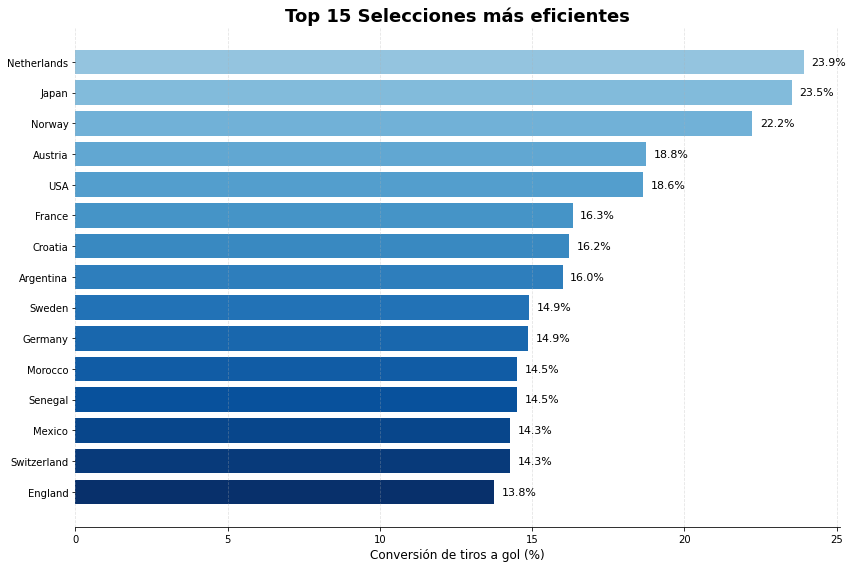

In [22]:
#equipos mas eficientes
import matplotlib.pyplot as plt
import numpy as np

# Top 15
top = eficiencia.sort_values(
    "conversion",
    ascending=False
).head(15)

fig, ax = plt.subplots(figsize=(12,8))

# Degradado de colores
colors = plt.cm.Blues(np.linspace(0.4,1,len(top)))

bars = ax.barh(
    top.index,
    top["conversion"],
    color=colors
)

ax.invert_yaxis()

ax.set_title(
    "Top 15 Selecciones más eficientes",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel(
    "Conversión de tiros a gol (%)",
    fontsize=12
)

# Mostrar porcentaje al final
for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.25,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=11
    )

# Cuadrícula
ax.grid(axis="x", linestyle="--", alpha=.35)

# Quitar bordes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.show()

In [23]:
import pandas as pd

# Local
home = matches[[
    "home_team",
    "home_score",
    "home_total_shots"
]].rename(columns={
    "home_team":"team",
    "home_score":"goals",
    "home_total_shots":"shots"
})

# Visitante
away = matches[[
    "away_team",
    "away_score",
    "away_total_shots"
]].rename(columns={
    "away_team":"team",
    "away_score":"goals",
    "away_total_shots":"shots"
})

teams = pd.concat([home, away])

resumen = (
    teams
    .groupby("team")
    .agg(
        partidos=("team","count"),
        goles=("goals","sum"),
        tiros=("shots","sum")
    )
)

resumen["tiros_partido"] = resumen["tiros"] / resumen["partidos"]

resumen["conversion"] = (
    resumen["goles"] /
    resumen["tiros"] * 100
)

resumen.head()

,partidos,goles,tiros,tiros_partido,conversion
team,,,,,
Algeria,4,5.0,44.0,11.000000,11.363636
Argentina,5,12.0,75.0,15.000000,16.000000
Australia,4,3.0,42.0,10.500000,7.142857
Austria,4,6.0,32.0,8.000000,18.750000
Belgium,6,13.0,112.0,18.666667,11.607143


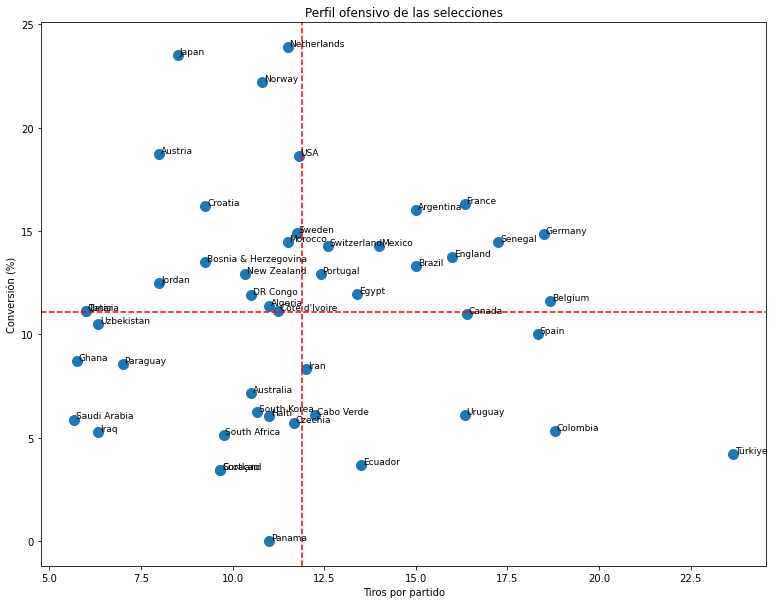

In [24]:
x = resumen["tiros_partido"].mean()
y = resumen["conversion"].mean()

plt.figure(figsize=(13,10))

plt.scatter(
    resumen["tiros_partido"],
    resumen["conversion"],
    s=100
)

plt.axvline(x,color="red",linestyle="--")
plt.axhline(y,color="red",linestyle="--")

for equipo in resumen.index:

    plt.text(
        resumen.loc[equipo,"tiros_partido"]+0.05,
        resumen.loc[equipo,"conversion"]+0.05,
        equipo,
        fontsize=9
    )

plt.xlabel("Tiros por partido")

plt.ylabel("Conversión (%)")

plt.title("Perfil ofensivo de las selecciones")

plt.show()

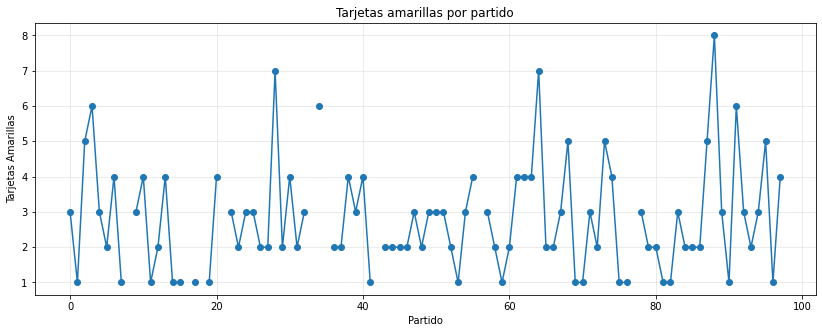

In [25]:
matches["yellow_cards"] = (
    matches.home_yellow_cards +
    matches.away_yellow_cards
)

plt.figure(figsize=(14,5))

plt.plot(
    matches.index,
    matches["yellow_cards"],
    marker="o"
)

plt.xlabel("Partido")

plt.ylabel("Tarjetas Amarillas")

plt.title("Tarjetas amarillas por partido")

plt.grid(alpha=.3)

plt.show()

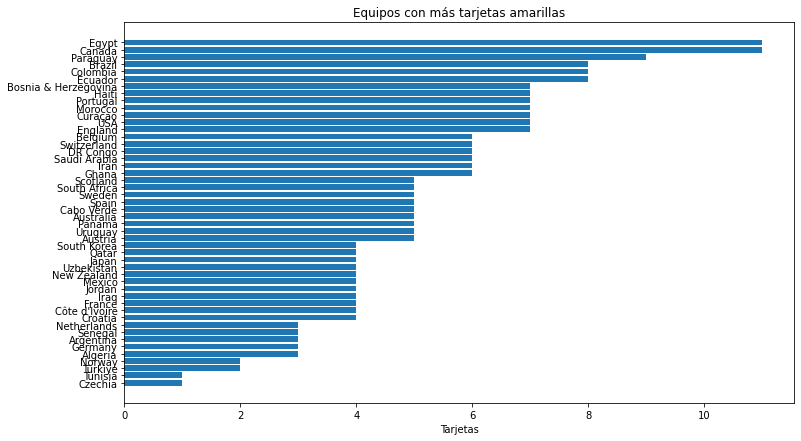

In [26]:

home = matches[
    ["home_team","home_yellow_cards"]
].rename(columns={
    "home_team":"team",
    "home_yellow_cards":"yellow"
})

away = matches[
    ["away_team","away_yellow_cards"]
].rename(columns={
    "away_team":"team",
    "away_yellow_cards":"yellow"
})

cards = pd.concat([home,away])

cards = (
    cards
    .groupby("team")
    .sum()
    .sort_values(
        "yellow",
        ascending=False
    )
)

plt.figure(figsize=(12,7))

plt.barh(
    cards.index,
    cards.yellow
)

plt.title("Equipos con más tarjetas amarillas")

plt.xlabel("Tarjetas")

plt.gca().invert_yaxis()

plt.show()

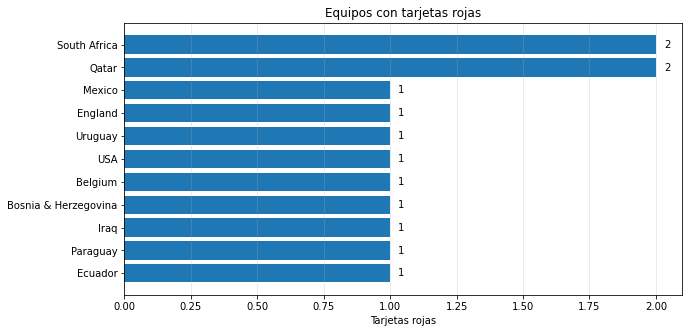

In [27]:
home = matches[["home_team","home_red_cards"]].rename(columns={
    "home_team":"team",
    "home_red_cards":"red"
})

away = matches[["away_team","away_red_cards"]].rename(columns={
    "away_team":"team",
    "away_red_cards":"red"
})

red = pd.concat([home, away])

red = (
    red.groupby("team")["red"]
       .sum()
       .sort_values(ascending=False)
)

# Solo equipos con al menos una roja
red = red[red > 0]

plt.figure(figsize=(10,5))

bars = plt.barh(red.index, red.values)

plt.title("Equipos con tarjetas rojas")
plt.xlabel("Tarjetas rojas")

# Mostrar el valor
for bar in bars:
    plt.text(
        bar.get_width()+0.03,
        bar.get_y()+bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=.3)

plt.show()

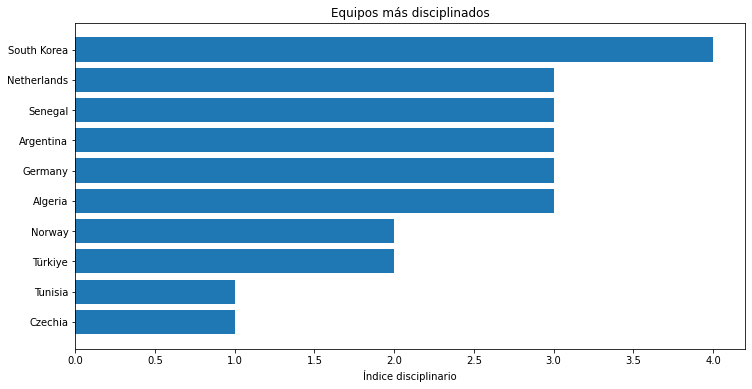

In [28]:
disciplina = cards.join(red, how="left").fillna(0)

disciplina["total"] = (
    disciplina["yellow"] +
    disciplina["red"]*2
)

disciplina = disciplina.sort_values("total")

plt.figure(figsize=(12,6))

plt.barh(
    disciplina.head(10).index,
    disciplina.head(10).total
)

plt.title("Equipos más disciplinados")

plt.xlabel("Índice disciplinario")

plt.show()